# Spacehopper Gripper Data Evaluation\nThis notebook processes the raw ROS logs from the physical gripper tests on various rock surfaces. It trims the initial offsets, identifies the point of slippage (when Tangential Force Fx drops), and plots the Maximum Normal Force (Fz) vs Tangential Force prior to slippage. The calculated statistics are then used to evaluate the gripper's holding performance.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
def plot_forces(df, cut_1=0, cut_2=None, avg_end=None, fx_threshold=1, offset_position='beginning', offset_length=10):
    """
    Plots the Tangential Force (Fx) and Normal Force (Fz) from the given DataFrame with offsets
    and within a specified range.

    Parameters:
    df (pd.DataFrame): The DataFrame containing force data with columns 'Fx' and 'Fz'.
    cut_1 (int): The starting index for the range of data to be plotted.
    cut_2 (int or None): The ending index for the range of data to be plotted. If None, plot till the end.

    Returns:
    None
    """
    if offset_position == 'beginning':
        # Calculate the offsets as the average of the first 20 entries
        offset_x = df['Fx'][:offset_length].mean()
        offset_z = df['Fz'][:offset_length].mean()
    elif offset_position == 'end':
        # Calculate the offsets as the average of the last 20 entries
        offset_x = df['Fx'][-offset_length:].mean()
        offset_z = df['Fz'][-offset_length:].mean()
    else:
        raise ValueError("Invalid offset_position. Choose either 'beginning' or 'end'.")

    # If avg_end is not provided, use cut_2
    avg_end = avg_end if avg_end is not None else cut_2

    # If avg_end is not None, calculate the length from cut_1 to avg_end
    if avg_end is not None and cut_1 is not None:
        length_cut_to_avg = avg_end - cut_1
        print(f"Length from cut_1 to avg_end: {length_cut_to_avg}")

    # Calculate average values of Fx and Fz in the defined averaging interval
    avg_fx = df[cut_1:avg_end]['Fx'].mean() - offset_x
    avg_fz = df[cut_1:avg_end]['Fz'].mean() - offset_z

    # Apply the cut range to the DataFrame
    df_cut = df[cut_1:cut_2].copy()
    
    # Find the maximum Fz and corresponding timestep
    max_fz = df_cut['Fz'].max() - offset_z
    max_fz_timestep = df_cut['Fz'].idxmax()

    # Find the timestep where Fx drops below the threshold
    fx_drop_timestep = df_cut[df_cut['Fx'] - offset_x < fx_threshold].index.min()
    
    # Print the average values
    print(f"Average Fx in the averaging interval [{cut_1}:{avg_end}]: {avg_fx}")
    print(f"Average Fz in the averaging interval [{cut_1}:{avg_end}]: {avg_fz}")
    print(f"Maximum Fz in the plotting interval [{cut_1}:{cut_2}]: {max_fz} at timestep {max_fz_timestep}")
    print(f"Time step where Fx drops below {fx_threshold}: {fx_drop_timestep}")
    
    plt.figure(figsize=(10, 5))
    plt.plot(df_cut['Fx'] - offset_x, label='Tangential Force (Fx)', alpha=0.7)
    plt.plot(df_cut['Fz'] - offset_z, label='Normal Force (Fz)', alpha=0.7)
    plt.axvline(x=max_fz_timestep, color='r', linestyle='--', label='Max Fz', alpha=0.2)
    plt.axvline(x=fx_drop_timestep, color='g', linestyle='--', label=f'Fx < {fx_threshold}', alpha=0.2)
    plt.xlabel('Timesteps')
    plt.ylabel('Force (N)')
    plt.legend()
    plt.title('Tangential vs Normal Force (Offset Adjusted)')
    plt.grid()
    plt.show()

    # Apply the offsets to the cut DataFrame
    df_cut['Fx'] = df_cut['Fx'] - offset_x
    df_cut['Fz'] = df_cut['Fz'] - offset_z
    
    # Shift the index so it starts at 0 if cut_1 is not None
    if cut_1 is not None:
        df_cut.index = df_cut.index - cut_1

    # Return the modified DataFrame
    return df_cut, (length_cut_to_avg if avg_end is not None and cut_1 is not None else None)

<font size="6">Lavarock 40°</font>

<font size="6">Test 1: (worked (kind of))</font>

Length from cut_1 to avg_end: 2390
Average Fx in the averaging interval [530:2920]: 4.792176145622753
Average Fz in the averaging interval [530:2920]: 6.316174614346344
Maximum Fz in the plotting interval [530:None]: 14.132979329427084 at timestep 2920
Time step where Fx drops below 1: 1417


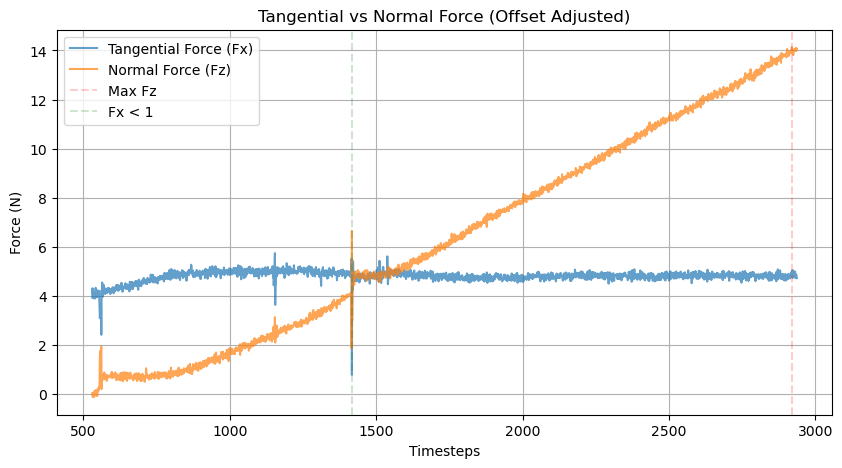

In [3]:
data = "../raw_data/Gripper Test Microspines Angles//Lavarock_40_5N//log_202405231641.csv"
df = pd.read_csv(data)
test_1, end_1 = plot_forces(df, cut_1=530, cut_2=None, avg_end=2920, offset_position='beginning', offset_length=15, fx_threshold=1)

<font size="6">Test 2: (worked (kind of))</font>

Length from cut_1 to avg_end: 2936
Average Fx in the averaging interval [0:2936]: 1.9899624812083276
Average Fz in the averaging interval [0:2936]: 7.006960459276036
Maximum Fz in the plotting interval [0:None]: 15.220601399739584 at timestep 2936
Time step where Fx drops below 1: 25


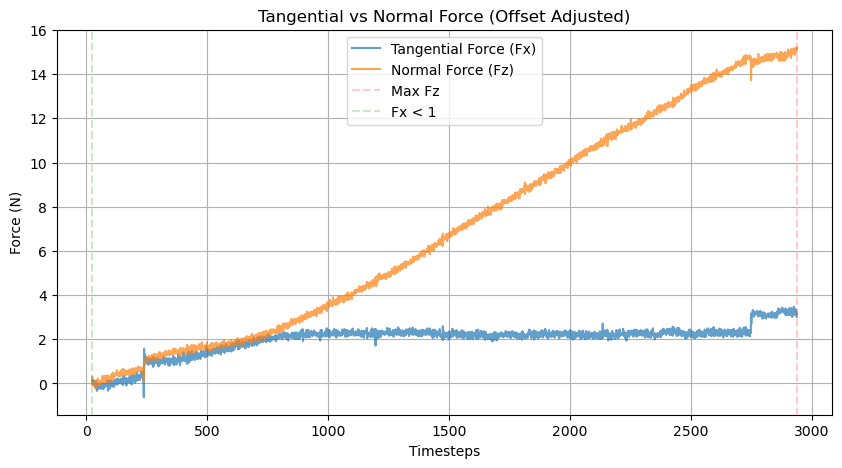

In [4]:
data = "../raw_data/Gripper Test Microspines Angles//Lavarock_40_5N//log_202405231642.csv"
df = pd.read_csv(data)
df = df[25:]
test_2, end_2 = plot_forces(df, cut_1=0, cut_2=None, avg_end=2936, offset_position='beginning', offset_length=15)

<font size="6">Test 3: (worked)</font>

Length from cut_1 to avg_end: 478
Average Fx in the averaging interval [135:613]: 3.8634794629268567
Average Fz in the averaging interval [135:613]: 0.35268655987131703
Maximum Fz in the plotting interval [135:650]: 1.0132405598958334 at timestep 346
Time step where Fx drops below 1: 613


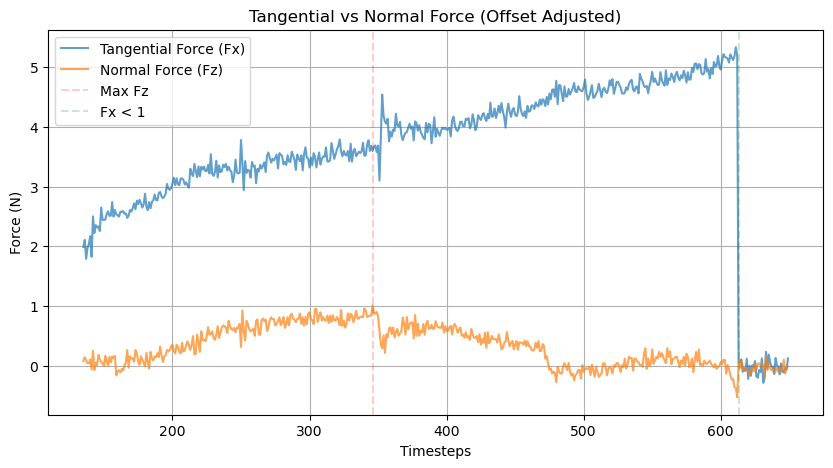

In [5]:
data = "../raw_data/Gripper Test Microspines Angles//Lavarock_40_5N//log_202405231650.csv"
df = pd.read_csv(data)
test_3, end_3 = plot_forces(df, cut_1=135, cut_2=650, avg_end=613, offset_position='end', offset_length=15, fx_threshold=1)

<font size="6">Test 4: (worked)</font>

Length from cut_1 to avg_end: 839
Average Fx in the averaging interval [1185:2024]: 5.423265146422963
Average Fz in the averaging interval [1185:2024]: 2.359608369144505
Maximum Fz in the plotting interval [1185:None]: 5.187626139322917 at timestep 1767
Time step where Fx drops below 1: 1766


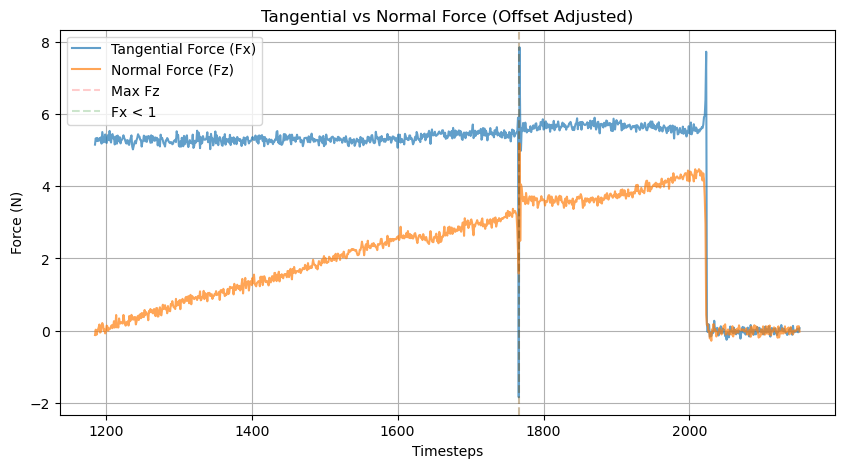

In [6]:
data = "../raw_data/Gripper Test Microspines Angles//Lavarock_40_5N//log_202405231651.csv"
df = pd.read_csv(data)
test_4, end_4 = plot_forces(df, cut_1=1185, cut_2=None, avg_end=2024, offset_position='end', offset_length=15)

<font size="6">Test 5: (worked)</font>

Length from cut_1 to avg_end: 2236
Average Fx in the averaging interval [60:2296]: 4.427993653456086
Average Fz in the averaging interval [60:2296]: 4.235952847957895
Maximum Fz in the plotting interval [60:None]: 8.899527994791667 at timestep 2115
Time step where Fx drops below 1: 60


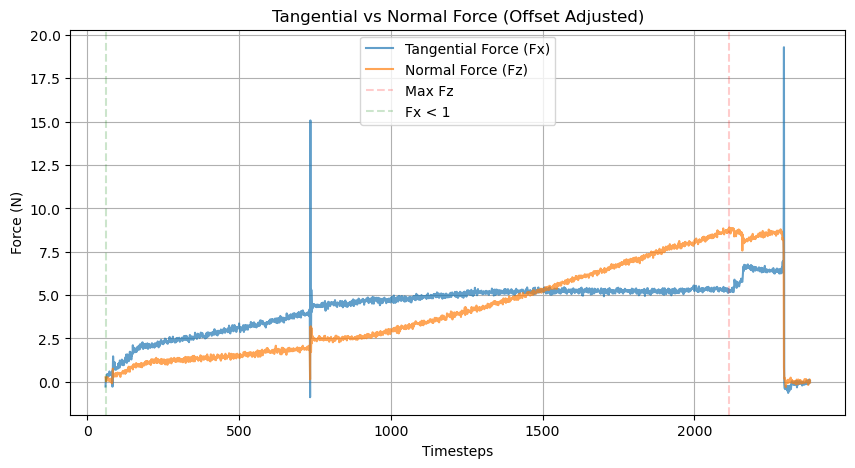

In [7]:
data = "../raw_data/Gripper Test Microspines Angles//Lavarock_40_5N//log_202405231653.csv"
df = pd.read_csv(data)
test_5, end_5 = plot_forces(df, cut_1=60, cut_2=None, avg_end=2296, offset_position='end', offset_length=15)

<font size="6">Test 6: (worked)</font>

Length from cut_1 to avg_end: 945
Average Fx in the averaging interval [500:1445]: 4.294354067908393
Average Fz in the averaging interval [500:1445]: 1.429170994026951
Maximum Fz in the plotting interval [500:None]: 3.896232096354167 at timestep 1431
Time step where Fx drops below 1: 1445


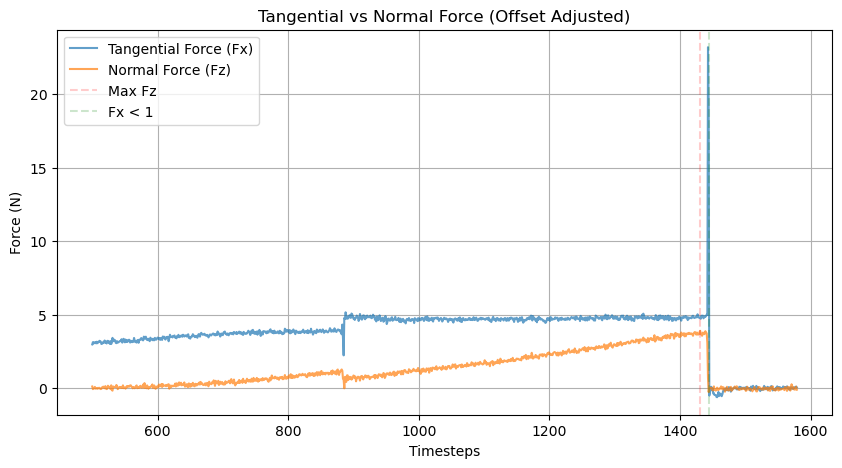

In [8]:
data = "../raw_data/Gripper Test Microspines Angles//Lavarock_40_5N//log_202405231700.csv"
df = pd.read_csv(data)
test_6, end_6 = plot_forces(df, cut_1=500, cut_2=None, avg_end=1445, offset_position='end', offset_length=15)

<font size="6">Test 7: (partially worked / failed)</font>

Length from cut_1 to avg_end: 70
Average Fx in the averaging interval [750:820]: 3.6002687772115074
Average Fz in the averaging interval [750:820]: 0.18825596400669653
Maximum Fz in the plotting interval [750:875]: 0.5081787109375 at timestep 818
Time step where Fx drops below 1: 820


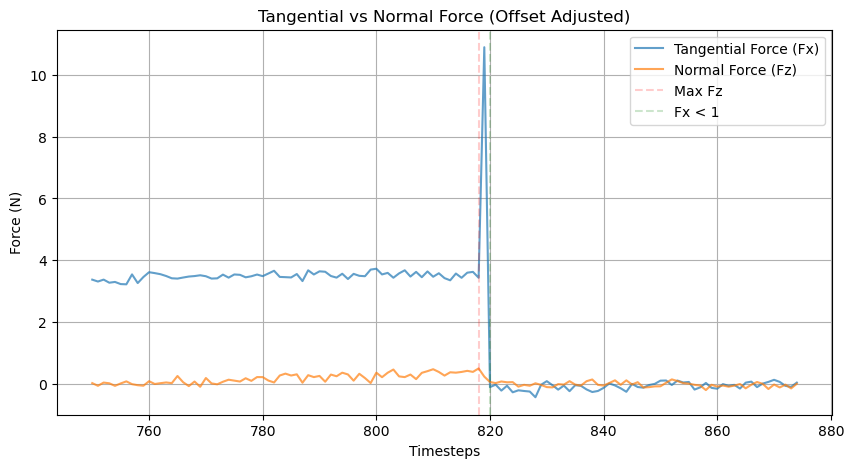

In [9]:
data = "../raw_data/Gripper Test Microspines Angles//Lavarock_40_5N//log_202405231702.csv"
df = pd.read_csv(data)
test_7, end_7 = plot_forces(df, cut_1=750, cut_2=875, avg_end=820, offset_position='end', offset_length=15)

<font size="6">Test 8a: (worked)</font>

Length from cut_1 to avg_end: 525
Average Fx in the averaging interval [90:615]: 4.721960262116932
Average Fz in the averaging interval [90:615]: 1.7992081705729166
Maximum Fz in the plotting interval [90:640]: 2.60755615234375 at timestep 568
Time step where Fx drops below 1: 615


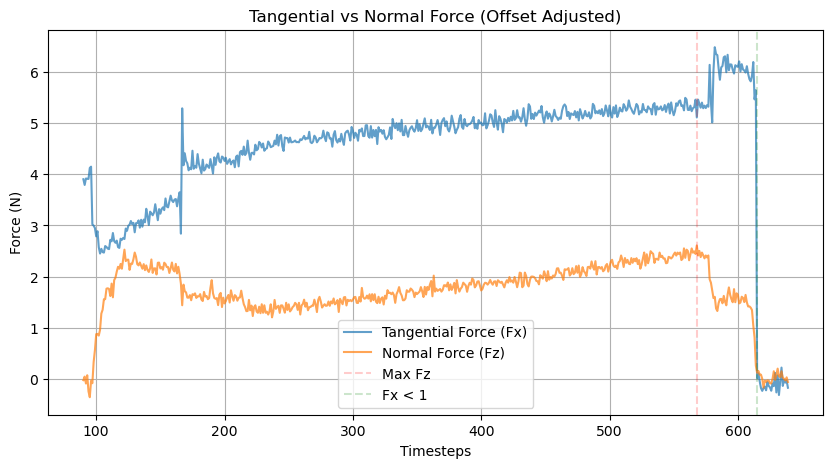

In [10]:
data = "../raw_data/Gripper Test Microspines Angles//Lavarock_40_5N//log_202405231705.csv"
df = pd.read_csv(data)
test_8a, end_8a = plot_forces(df, cut_1=90, cut_2=640, avg_end=615, offset_position='beginning', offset_length=15)

<font size="6">Test 8b: (worked)</font>

Length from cut_1 to avg_end: 1105
Average Fx in the averaging interval [1430:2535]: 3.903550363198305
Average Fz in the averaging interval [1430:2535]: 3.7880743380585407
Maximum Fz in the plotting interval [1430:2650]: 7.49837646484375 at timestep 2525
Time step where Fx drops below 1: 2535


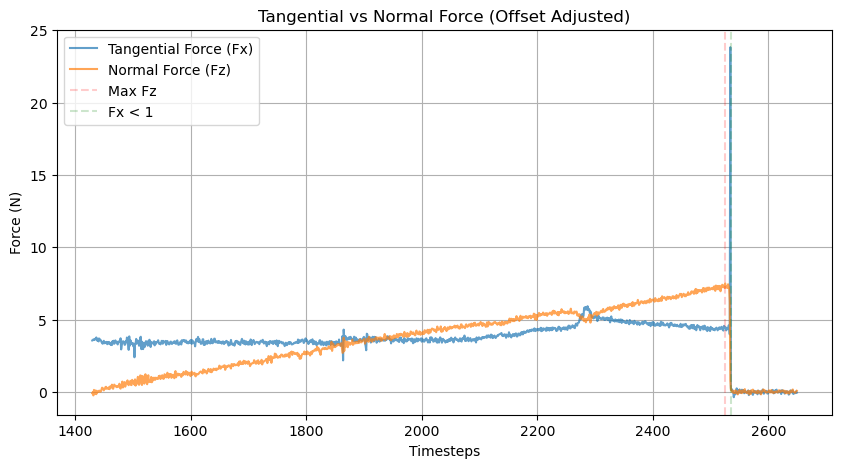

In [11]:
data = "../raw_data/Gripper Test Microspines Angles//Lavarock_40_5N//log_202405231705.csv"
df = pd.read_csv(data)
test_8b, end_8b = plot_forces(df, cut_1=1430, cut_2=2650, avg_end=2535, offset_position='end', offset_length=15)

<font size="6">Test 9: (worked)</font>

Length from cut_1 to avg_end: 225
Average Fx in the averaging interval [630:855]: 4.842083280351427
Average Fz in the averaging interval [630:855]: 0.3427086046006944
Maximum Fz in the plotting interval [630:None]: 0.8588134765625 at timestep 839
Time step where Fx drops below 1: 855


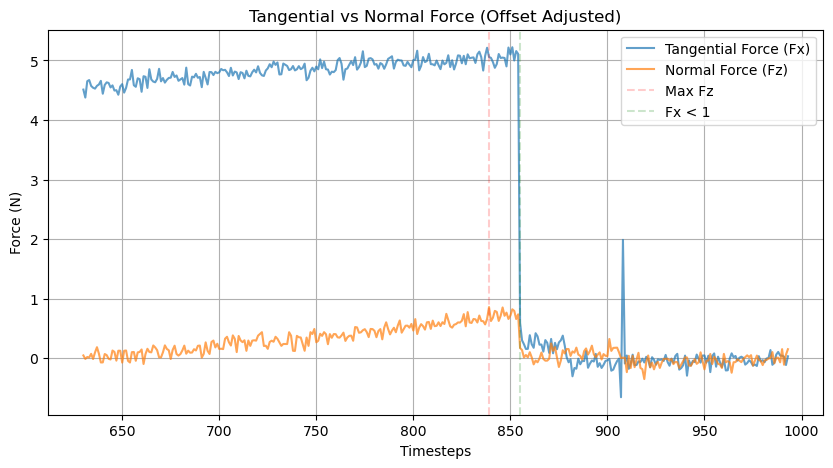

In [12]:
data = "../raw_data/Gripper Test Microspines Angles//Lavarock_40_5N//log_202405231706.csv"
df = pd.read_csv(data)
test_9, end_9 = plot_forces(df, cut_1=630, cut_2=None, avg_end=855, offset_position='end', offset_length=15)

<font size="6">Test 10: (worked)</font>

Length from cut_1 to avg_end: 1430
Average Fx in the averaging interval [670:2100]: 3.422039806425988
Average Fz in the averaging interval [670:2100]: 3.9001385455364947
Maximum Fz in the plotting interval [670:None]: 8.08109130859375 at timestep 2076
Time step where Fx drops below 1: 2100


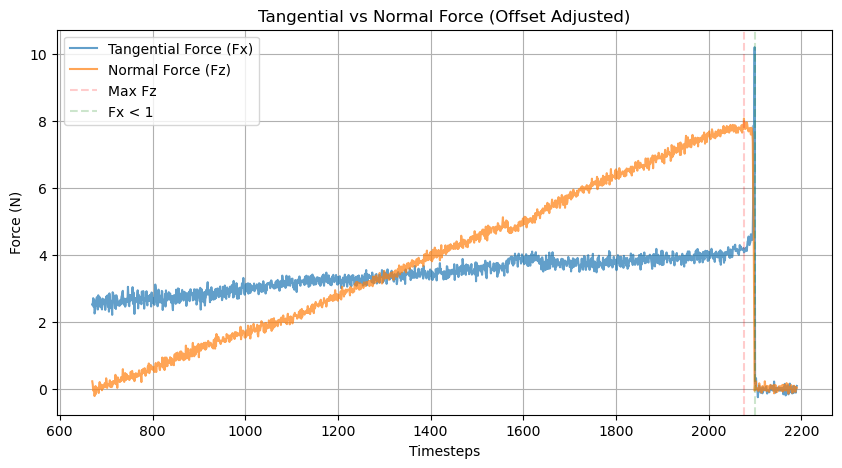

In [13]:
data = "../raw_data/Gripper Test Microspines Angles//Lavarock_40_5N//log_202405231715.csv"
df = pd.read_csv(data)
test_10, end_10 = plot_forces(df, cut_1=670, cut_2=None, avg_end=2100, offset_position='end', offset_length=15)

In [14]:
def plot_multiple_tests(tests, ends):
    # Find the maximum length among all datasets
    max_length = max([end for end in ends if end is not None])
    
    plt.figure(figsize=(15, 7))
    
    for i, (test, end) in enumerate(zip(tests, ends)):
        if end is not None:
            fz_series = test['Fz']
            fz_series_cut = fz_series[:end]
            if len(fz_series_cut) < max_length:
                padded_fz = np.pad(fz_series_cut.values, (0, max_length - len(fz_series_cut)), 'constant', constant_values=np.nan)
            else:
                padded_fz = fz_series_cut.values
            plt.plot(padded_fz, label=f'Dataset {i+1} Fz', alpha=0.6)
        
    plt.xlabel('Adjusted Timesteps')
    plt.ylabel('Normal Force (Fz) (N)')
    plt.legend()
    plt.title('Normal Force (Fz) of Multiple Datasets')
    plt.grid()
    plt.show()

In [18]:
def calculate_statistics(tests, ends):
    max_fz_values = []
    avg_fz_values = []
    avg_fx_values = []
    
    for test, end in zip(tests, ends):
        if end is not None:
            fz_series = test['Fz']
            fx_series = test['Fx']
            fz_series_cut = fz_series[:end]
            fx_series_cut = fx_series[:end]
            max_fz_values.append(fz_series_cut.max())
            avg_fz_values.append(fz_series_cut.mean())
            avg_fx_values.append(fx_series_cut.mean())
    
    average_max_fz = np.mean(max_fz_values)
    std_max_fz = np.std(max_fz_values)
    
    average_avg_fz = np.mean(avg_fz_values)
    std_avg_fz = np.std(avg_fz_values)
    
    average_avg_fx = np.mean(avg_fx_values)
    std_avg_fx = np.std(avg_fx_values)
    
    print(f"Average of maximum Fz forces: {average_max_fz}")
    print(f"Standard deviation of maximum Fz forces: {std_max_fz}")
    print(f"Average of average Fz forces: {average_avg_fz}")
    print(f"Standard deviation of average Fz forces: {std_avg_fz}")
    print(f"Average of average Fx forces: {average_avg_fx}")
    print(f"Standard deviation of average Fx forces: {std_avg_fx}")
    
    # Create a dictionary to store the statistics
    statistics_dict = {
        'Statistic': ['Average Max Fz', 'Std Max Fz', 'Average Avg Fz', 'Std Avg Fz', 'Average Avg Fx', 'Std Avg Fx'],
        'Value': [average_max_fz, std_max_fz, average_avg_fz, std_avg_fz, average_avg_fx, std_avg_fx]
    }
    
    # Convert the dictionary to a DataFrame
    statistics_df = pd.DataFrame(statistics_dict)
    
    # Save the statistics to a CSV file
    statistics_df.to_csv("../raw_data/Gripper Test Microspines Angles//40//Lavarock_40_stats.csv", index=False)

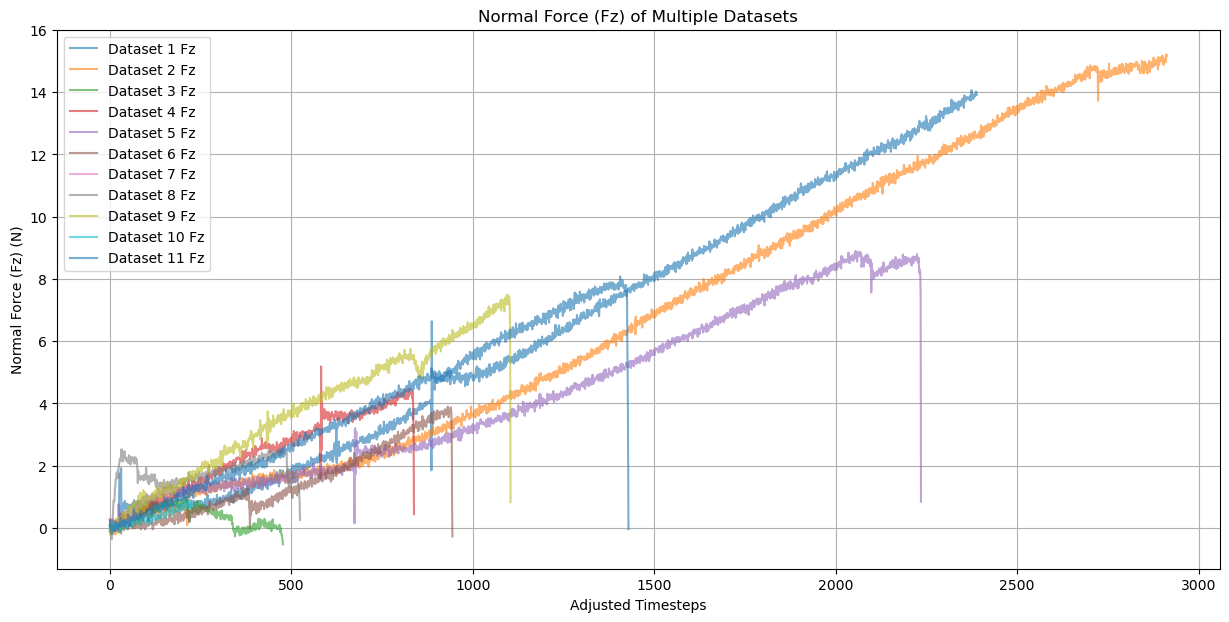

Average of maximum Fz forces: 6.166730291193182
Standard deviation of maximum Fz forces: 4.8874583223238295
Average of average Fz forces: 2.8835399515816724
Standard deviation of average Fz forces: 2.259471390070399
Average of average Fx forces: 4.116466676986321
Standard deviation of average Fx forces: 0.8824648010215463


In [19]:
tests = [test_1, test_2, test_3, test_4, test_5, test_6, test_7, test_8a, test_8b, test_9, test_10]
ends = [end_1, end_2, end_3, end_4, end_5, end_6, end_7, end_8a, end_8b, end_9, end_10]
plot_multiple_tests(tests, ends)
calculate_statistics(tests, ends)

In [20]:
def save_tests_to_csv_cut(tests, ends, file_prefix="../raw_data/Gripper Test Microspines Angles//40//Lavarock_40"):
    # Save each test dataset to a separate CSV file, cutting at the end point
    for i, (test, end) in enumerate(zip(tests, ends)):
        test_cut = test.iloc[:end] if end is not None else test  # Cut the test data at the end point
        test_cut.to_csv(f'{file_prefix}_{i+1}.csv', index=False)

save_tests_to_csv_cut(tests, ends)